In [36]:
import pandas as pd

data = pd.read_csv("https://raw.githubusercontent.com/drolsonmi/math3480/refs/heads/main/datasets/young-people-survey-responses.csv")
data.head(5)


,Unnamed: 0,Music,Techno,Movies,History,Mathematics,Pets,Spiders,Loneliness,Parents' advice,Internet usage,Finances,Age,Siblings,Gender,Village - town
0,0,5.0,1.0,5.0,1.0,3.0,4.0,1.0,3.0,4.0,few hours a day,3.0,20.0,1.0,female,village
1,1,4.0,1.0,5.0,1.0,5.0,5.0,1.0,2.0,2.0,few hours a day,3.0,19.0,2.0,female,city
2,2,5.0,1.0,5.0,1.0,5.0,5.0,1.0,5.0,3.0,few hours a day,2.0,20.0,2.0,female,city
3,3,5.0,2.0,5.0,4.0,4.0,1.0,5.0,5.0,2.0,most of the day,2.0,22.0,1.0,female,city
4,4,5.0,2.0,5.0,3.0,2.0,1.0,1.0,3.0,3.0,few hours a day,4.0,20.0,1.0,female,village


In [8]:
print(data.isnull().sum()/len(data) *100)

Unnamed: 0         0.000000
Music              0.297030
Techno             0.693069
Movies             0.594059
History            0.198020
Mathematics        0.297030
Pets               0.396040
Spiders            0.495050
Loneliness         0.099010
Parents' advice    0.198020
Internet usage     0.000000
Finances           0.297030
Age                0.693069
Siblings           0.594059
Gender             0.594059
Village - town     0.396040
dtype: float64


In [9]:
import numpy as np
male_finance_average = np.mean(data[data['Gender'] == 'male']['Finances'])
female_finance_average = np.mean(data[data['Gender'] == 'female']['Finances'])
average_age = np.mean(data['Age'])

data.loc[data['Gender'] == 'male', 'Finances'] = data.loc[data['Gender'] == 'male', 'Finances'].fillna(male_finance_average)
data.loc[data['Gender'] == 'female', 'Finances'] = data.loc[data['Gender'] == 'female', 'Finances'].fillna(female_finance_average)

data['Age'] = data['Age'].fillna(average_age)

display(data.head())

,Unnamed: 0,Music,Techno,Movies,History,Mathematics,Pets,Spiders,Loneliness,Parents' advice,Internet usage,Finances,Age,Siblings,Gender,Village - town
0,0,5.0,1.0,5.0,1.0,3.0,4.0,1.0,3.0,4.0,few hours a day,3.0,20.0,1.0,female,village
1,1,4.0,1.0,5.0,1.0,5.0,5.0,1.0,2.0,2.0,few hours a day,3.0,19.0,2.0,female,city
2,2,5.0,1.0,5.0,1.0,5.0,5.0,1.0,5.0,3.0,few hours a day,2.0,20.0,2.0,female,city
3,3,5.0,2.0,5.0,4.0,4.0,1.0,5.0,5.0,2.0,most of the day,2.0,22.0,1.0,female,city
4,4,5.0,2.0,5.0,3.0,2.0,1.0,1.0,3.0,3.0,few hours a day,4.0,20.0,1.0,female,village


In [10]:
print("# of rows: " + str(len(data)))
print("# of columns: " + str(len(data.columns)))
data = data.dropna()


print("# of rows: " + str(len(data)))
print("# of columns: " + str(len(data.columns)))

# of rows: 1010
# of columns: 16
# of rows: 966
# of columns: 16


# Categoric
## Ordinal
- Internet usage
## Nominal
- Gender
- Village-town



In [11]:
def OneHotEncode(data, column):
  temp_data = data[column]
  temp_data = pd.get_dummies(temp_data).astype(int)
  data = pd.concat([data, temp_data], axis=1)
  data = data.drop(column, axis=1)
  return data

data = OneHotEncode(data, 'Gender')
data = OneHotEncode(data, 'Village - town')
data.head()

,Unnamed: 0,Music,Techno,Movies,History,Mathematics,Pets,Spiders,Loneliness,Parents' advice,Internet usage,Finances,Age,Siblings,female,male,city,village
0,0,5.0,1.0,5.0,1.0,3.0,4.0,1.0,3.0,4.0,few hours a day,3.0,20.0,1.0,1,0,0,1
1,1,4.0,1.0,5.0,1.0,5.0,5.0,1.0,2.0,2.0,few hours a day,3.0,19.0,2.0,1,0,1,0
2,2,5.0,1.0,5.0,1.0,5.0,5.0,1.0,5.0,3.0,few hours a day,2.0,20.0,2.0,1,0,1,0
3,3,5.0,2.0,5.0,4.0,4.0,1.0,5.0,5.0,2.0,most of the day,2.0,22.0,1.0,1,0,1,0
4,4,5.0,2.0,5.0,3.0,2.0,1.0,1.0,3.0,3.0,few hours a day,4.0,20.0,1.0,1,0,0,1


In [12]:
from typing import Set
categories = set(data['Internet usage'])
categories

{'few hours a day',
 'less than an hour a day',
 'most of the day',
 'no time at all'}

In [13]:
from sklearn.preprocessing import OrdinalEncoder
def OrdinalEncode(categories, data, col):
  enc = OrdinalEncoder(categories=[categories])
  data[col] = enc.fit_transform(data[[col]])
  return data

data = OrdinalEncode(['no time at all',
  'less than an hour a day',
  'few hours a day',
  'most of the day'
  ], data, 'Internet usage')
data.head(25)

,Unnamed: 0,Music,Techno,Movies,History,Mathematics,Pets,Spiders,Loneliness,Parents' advice,Internet usage,Finances,Age,Siblings,female,male,city,village
0,0,5.0,1.0,5.0,1.0,3.0,4.0,1.0,3.0,4.0,2.0,3.0,20.0,1.0,1,0,0,1
1,1,4.0,1.0,5.0,1.0,5.0,5.0,1.0,2.0,2.0,2.0,3.0,19.0,2.0,1,0,1,0
2,2,5.0,1.0,5.0,1.0,5.0,5.0,1.0,5.0,3.0,2.0,2.0,20.0,2.0,1,0,1,0
3,3,5.0,2.0,5.0,4.0,4.0,1.0,5.0,5.0,2.0,3.0,2.0,22.0,1.0,1,0,1,0
4,4,5.0,2.0,5.0,3.0,2.0,1.0,1.0,3.0,3.0,2.0,4.0,20.0,1.0,1,0,0,1
5,5,5.0,1.0,5.0,5.0,2.0,2.0,1.0,2.0,3.0,2.0,2.0,20.0,1.0,0,1,1,0
6,6,5.0,5.0,4.0,3.0,1.0,5.0,1.0,3.0,4.0,1.0,4.0,20.0,1.0,1,0,0,1
7,7,5.0,3.0,5.0,5.0,1.0,5.0,1.0,2.0,3.0,2.0,3.0,19.0,1.0,0,1,1,0
8,8,5.0,1.0,5.0,3.0,1.0,1.0,5.0,4.0,4.0,2.0,2.0,18.0,1.0,1,0,1,0
9,9,5.0,1.0,5.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,4.0,19.0,3.0,1,0,1,0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print(np.mean(data[data['Internet usage'] == 3.0]['Loneliness']))
print(np.mean(data[data['Internet usage'] == 2.0]['Loneliness']))
print(np.mean(data[data['Internet usage'] == 1.0]['Loneliness']))
print(np.mean(data[data['Internet usage'] == 0.0]['Loneliness']))

3.2100840336134455
2.893706293706294
2.5736434108527133
2.6666666666666665


/tmp/ipython-input-2047852172.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Internet usage', y='Loneliness',


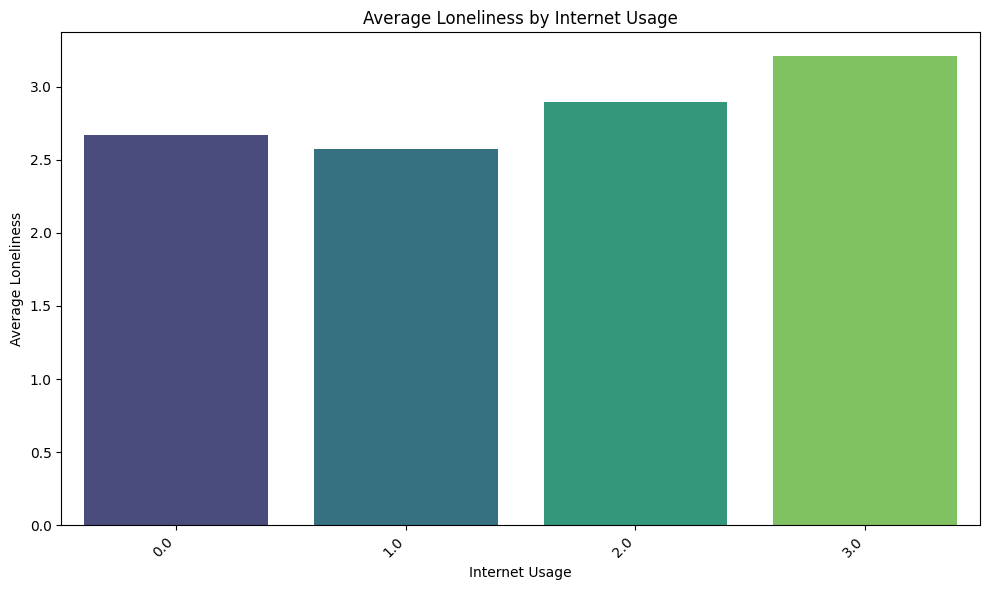

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

average_loneliness_by_internet_usage = data.groupby('Internet usage')['Loneliness'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Internet usage', y='Loneliness',
    data=average_loneliness_by_internet_usage,
    palette='viridis'
)
plt.title('Average Loneliness by Internet Usage')
plt.xlabel('Internet Usage')
plt.ylabel('Average Loneliness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2378884042.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age', y='Loneliness',


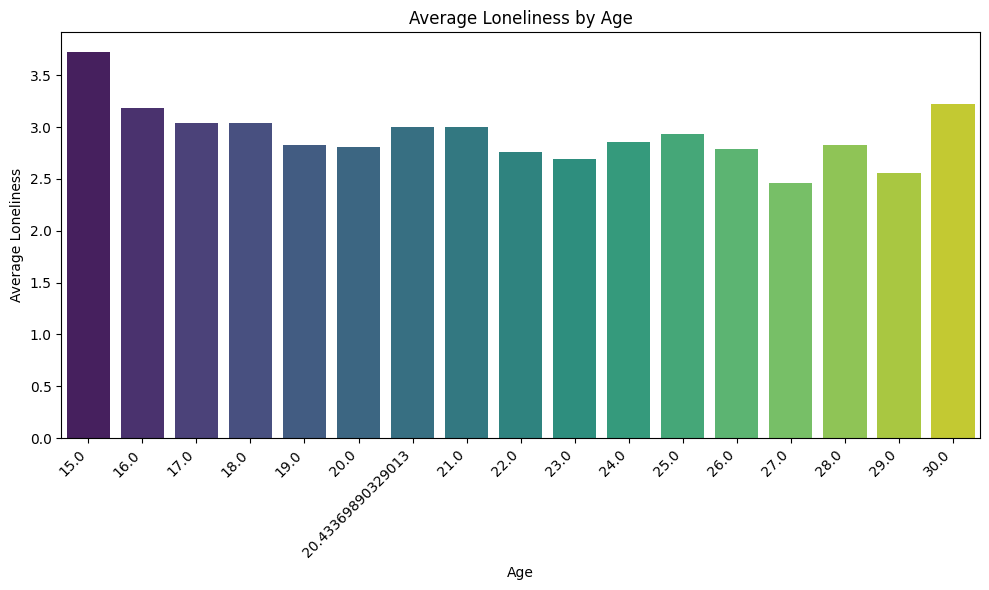

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

average_loneliness_by_age = data.groupby('Age')['Loneliness'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Age', y='Loneliness',
    data=average_loneliness_by_age,
    palette='viridis'
)
plt.title('Average Loneliness by Age')
plt.xlabel('Age')
plt.ylabel('Average Loneliness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
standarddata = data.copy()
standarddata = standarddata.drop('Unnamed: 0', axis=1)
def standardize(data, col):
  data[col] = (data[col] - data[col].mean()) / data[col].std()
  return data
for col in standarddata.columns:
  standarddata[col] = standardize(standarddata, col)
def hist(col, ax):
  average_loneliness_by_col = data.groupby(col)['Loneliness'].mean().reset_index()
  widths = data.value_counts(col)
  print(f"Column: {col}")
  print(widths)

  sns.barplot(x=col, y='Loneliness',
    data=average_loneliness_by_col,
    palette='viridis',
    ax=ax
  )
  ax.set_title(f'Average Loneliness by {col}')
  ax.set_xlabel(col)
  ax.set_ylabel('Average Loneliness')
  ax.tick_params(axis='x', rotation=45)

columns_to_plot = [c for c in data.columns if c not in ['Loneliness', 'Unnamed: 0']]

num_cols_to_plot = len(columns_to_plot)
ncols_grid = 5
nrows_grid = (num_cols_to_plot + ncols_grid - 1) // ncols_grid

fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(ncols_grid * 4, nrows_grid * 3))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
  if i < len(axes):
    hist(col, axes[i])

for j in range(num_cols_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


ValueError: Columns must be same length as key

/tmp/ipython-input-1528399017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=col, y='Loneliness', data=data, palette='viridis')


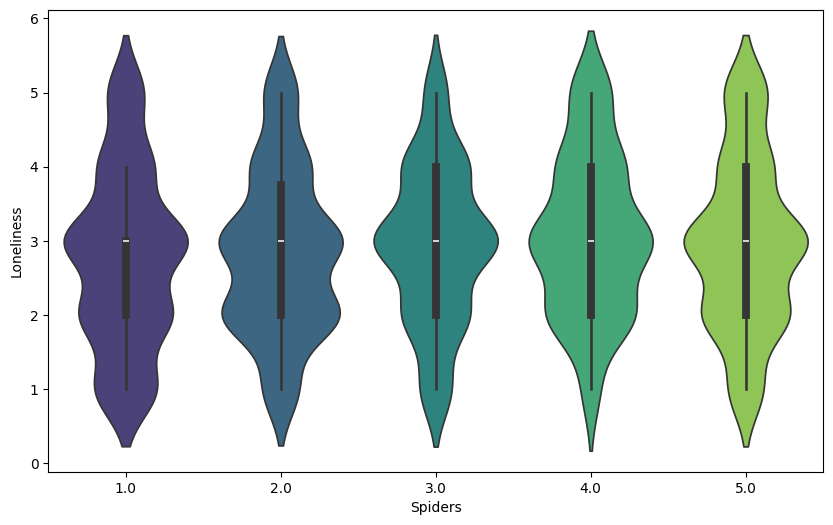

In [18]:
def violin(col):
  plt.figure(figsize=(10, 6))
  sns.violinplot(x=col, y='Loneliness', data=data, palette='viridis')
violin('Spiders')

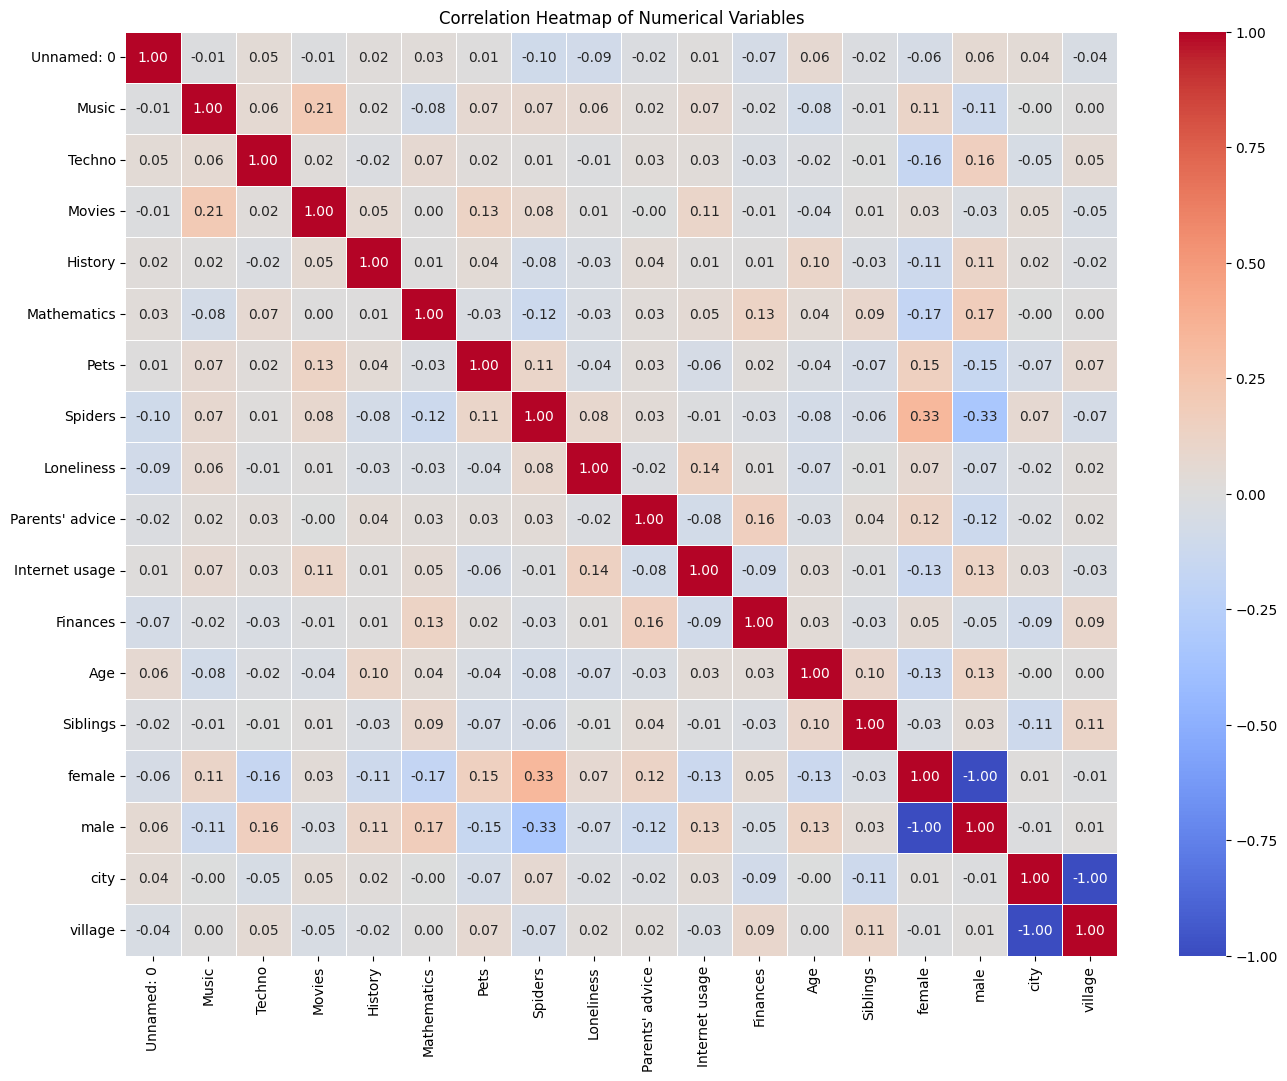

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = data.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

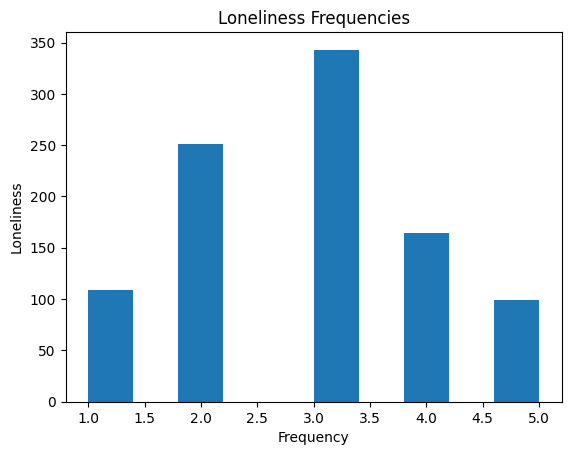

In [20]:
plt.hist(data['Loneliness'])

plt.xlabel('Frequency')
plt.ylabel('Loneliness')
plt.title('Loneliness Frequencies')
plt.show()

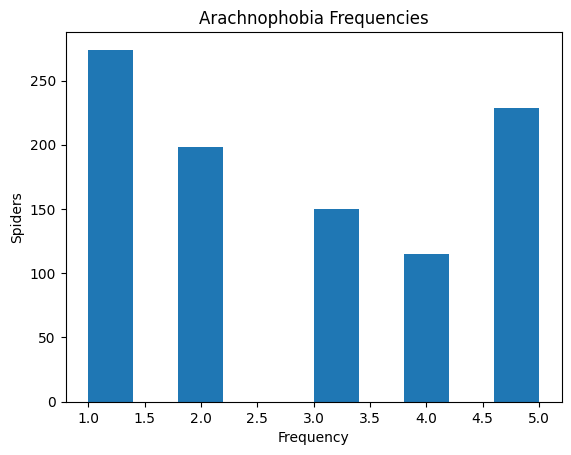

In [21]:
plt.hist(data['Spiders'])

plt.xlabel('Frequency')
plt.ylabel('Spiders')
plt.title('Arachnophobia Frequencies')
plt.show()

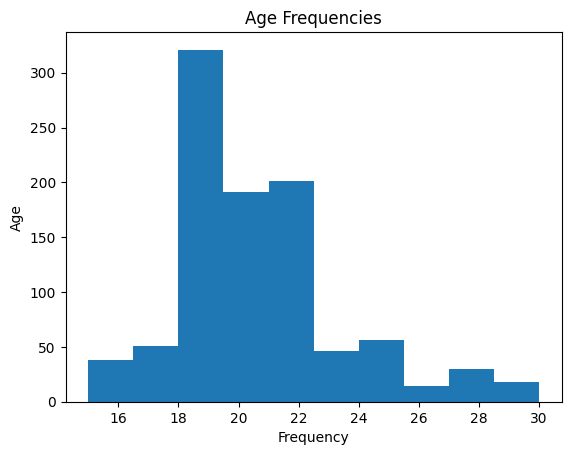

In [22]:
plt.hist(data['Age'])

plt.xlabel('Frequency')
plt.ylabel('Age')
plt.title('Age Frequencies')
plt.show()

In [23]:
def normalize(data, col):
  data[col] = (data[col] - data[col].min()) / (data[col].max() - data[col].min())
  return data

def standardize(data, col):
  data[col] = (data[col] - data[col].mean()) / data[col].std()
  return data

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('Loneliness', axis=1)
y = data['Loneliness']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



xfit = StandardScaler().fit(X_train)
yfit = StandardScaler().fit(y_train.values.reshape(-1, 1))

X_train = xfit.transform(X_train)
X_test = xfit.transform(X_test)
y_train = yfit.transform(y_train.values.reshape(-1, 1))
y_test = yfit.transform(y_test.values.reshape(-1, 1))
StandardScaler().fit_transform(X_test)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (772, 17)
Shape of X_test: (194, 17)
Shape of y_train: (772, 1)
Shape of y_test: (194, 1)


In [30]:
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor().fit(X_train, y_train.reshape(-1))
reg.score(X_test, y_test)

np.mean(reg.predict(X_test) - y_test)
def mse(y_true, y_pred):
  return np.mean((y_true - y_pred) ** 2)

mse(y_test, reg.predict(X_test))

np.float64(0.9661657266335199)

In [31]:
train_test_split_info = pd.DataFrame(index = ['training', 'testing'], data = {
    "samples": [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
    "% of Total": [X_train.shape[0] / data.shape[0] * 100, X_test.shape[0] / data.shape[0] * 100]
})
display(train_test_split_info)

,samples,features,% of Total
training,772,17,79.917184
testing,194,17,20.082816
